In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV

pd.set_option('display.max_columns', None)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time


In [2]:
# 1. Load the preprocessed data
df = pd.read_csv('../data/fevs_processed_for_ml.csv')

# 2. Separate target (y), predictors (X), and weights
y = df['Turnover_Intention']
weights = df['POSTWT']
X = df.drop(columns=['Turnover_Intention', 'POSTWT'])

# 3. Fill missing values (NaN) with -1 so the Baseline Model (Logistic) can run 
# (Tree models usually handle NaN themselves, but doing this to compare under the same conditions)
X_filled = X.fillna(-1)

print("Number of X (Features):", X_filled.shape[1])
print("Target Distribution:\n", y.value_counts(normalize=True))


Number of X (Features): 111
Target Distribution:
 Turnover_Intention
0    0.801565
1    0.198435
Name: proportion, dtype: float64


In [3]:
# Split 80% for Train, 20% for Test
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_filled, y, weights, test_size=0.2, stratify=y, random_state=42
)

print("Train Data Size:", X_train.shape)
print("Test Data Size:", X_test.shape)


Train Data Size: (401579, 111)
Test Data Size: (100395, 111)


In [4]:
# Define Dictionary of models to compete
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree (Interpretable)": DecisionTreeClassifier(random_state=42, max_depth=5),
    "XGBoost (Advanced)": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM (Advanced)": LGBMClassifier(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    # 1. Train by supplying sample weight to the algorithm
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # 2. Predict probabilities
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # 3. Calculate weighted ROC-AUC (primary distinction metric)
    auc = roc_auc_score(y_test, y_pred_prob, sample_weight=w_test)
    results.append({"Model": name, "Weighted ROC-AUC": auc})

# Display comparison results
df_results = pd.DataFrame(results).sort_values(by="Weighted ROC-AUC", ascending=False)
display(df_results)


,Model,Weighted ROC-AUC
3,LightGBM (Advanced),0.841952
2,XGBoost (Advanced),0.839618
1,Decision Tree (Interpretable),0.812759
0,Logistic Regression (Baseline),0.796917


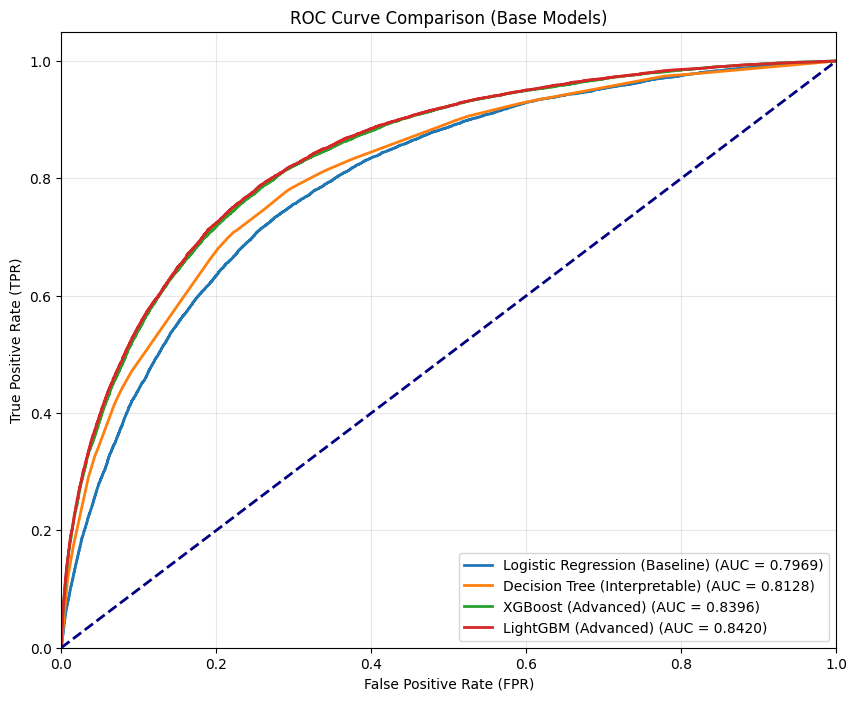

In [5]:
# 3.1 ROC Curve Comparison (Base Models)
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, sample_weight=w_test)
    auc_score = df_results[df_results['Model'] == name]['Weighted ROC-AUC'].values[0]
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison (Base Models)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
# --- LightGBM Tuning Experiment ---
# 4. LightGBM Tuning Methods (Baseline vs Randomized Search vs Optuna)
import time
import optuna
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

print("Starting Hyperparameter Tuning Comparison for LightGBM...")
results_lgbm = []

def evaluate_lgbm(model, name, X_test, y_test, w_test, train_time):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred, sample_weight=w_test)
    recall = recall_score(y_test, y_pred, sample_weight=w_test)
    auc = roc_auc_score(y_test, y_pred_prob, sample_weight=w_test)
    
    return {
        "Method": name,
        "Accuracy": accuracy,
        "Recall": recall,
        "ROC-AUC": auc,
        "Time (seconds)": train_time,
        "model": model
    }


Starting Hyperparameter Tuning Comparison for LightGBM...


/Users/barabank/Desktop/Folder/UE/Semester 4/Explainable Prediction of Public-Sector Employee Turnover Intention/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Method 1: Baseline Model (Microsoft Default) - Ke et al., 2017
print("\n--- 1. Baseline Model (Default) ---")
start_time = time.time()

lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)
lgbm_baseline.fit(X_train, y_train, sample_weight=w_train)

baseline_time = time.time() - start_time
res_baseline = evaluate_lgbm(lgbm_baseline, "Baseline (Default)", X_test, y_test, w_test, baseline_time)
results_lgbm.append(res_baseline)
print(f"Completed in {baseline_time:.2f} seconds. ROC-AUC: {res_baseline['ROC-AUC']:.4f}")



--- 1. Baseline Model (Default) ---
Completed in 2.36 seconds. ROC-AUC: 0.8420


In [8]:
# Method 2: Standard Statistical Tuning (Randomized Search) - Bergstra & Bengio, 2012
print("\n--- 2. Randomized Search (Bergstra & Bengio, 2012) ---")
from scipy.stats import randint, uniform

param_dist = {
    'num_leaves': randint(20, 100),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(100, 500),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_samples': randint(10, 50)
}

start_time = time.time()

lgbm_base = LGBMClassifier(random_state=42, verbose=-1)
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train, y_train, sample_weight=w_train)

random_time = time.time() - start_time
best_random_model = random_search.best_estimator_
res_random = evaluate_lgbm(best_random_model, "Randomized Search", X_test, y_test, w_test, random_time)
results_lgbm.append(res_random)
print(f"Completed in {random_time:.2f} seconds. ROC-AUC: {res_random['ROC-AUC']:.4f}")



--- 2. Randomized Search (Bergstra & Bengio, 2012) ---


/Users/barabank/Desktop/Folder/UE/Semester 4/Explainable Prediction of Public-Sector Employee Turnover Intention/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Completed in 320.65 seconds. ROC-AUC: 0.8441


In [9]:
# Method 3: Advanced Bayesian Tuning (Optuna) - Akiba et al., 2019
print("\n--- 3. Advanced Bayesian Tuning (Optuna) ---")

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.21),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'random_state': 42,
        'verbose': -1
    }
    
    # Internal validation split for Optuna
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_train, y_train, w_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, sample_weight=w_tr)
    
    y_pred_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_prob, sample_weight=w_val)
    return auc

optuna.logging.set_verbosity(optuna.logging.WARNING)

start_time = time.time()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Train best model on full train set
best_optuna_params = study.best_params
best_optuna_model = LGBMClassifier(**best_optuna_params, random_state=42, verbose=-1)
best_optuna_model.fit(X_train, y_train, sample_weight=w_train)

optuna_time = time.time() - start_time
res_optuna = evaluate_lgbm(best_optuna_model, "Optuna Bayesian Optimization", X_test, y_test, w_test, optuna_time)
results_lgbm.append(res_optuna)
print(f"Completed in {optuna_time:.2f} seconds. ROC-AUC: {res_optuna['ROC-AUC']:.4f}")



--- 3. Advanced Bayesian Tuning (Optuna) ---
Completed in 120.88 seconds. ROC-AUC: 0.8436


In [10]:
# 5. Final Comparison of Tuning Methods (For Chapter 5)
df_tuning_results = pd.DataFrame(results_lgbm)

# Format the dataframe for presentation
display_tuning_df = df_tuning_results.drop(columns=['model'])
display_tuning_df = display_tuning_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n=================== LIGHTGBM TUNING COMPARISON ===================")
display(display_tuning_df)



=================== LIGHTGBM TUNING COMPARISON ===================


,Method,Accuracy,Recall,ROC-AUC,Time (seconds)
0,Randomized Search,0.829626,0.433060,0.844099,320.647361
1,Optuna Bayesian Optimization,0.830020,0.431399,0.843593,120.875174
2,Baseline (Default),0.828923,0.424485,0.841952,2.359066


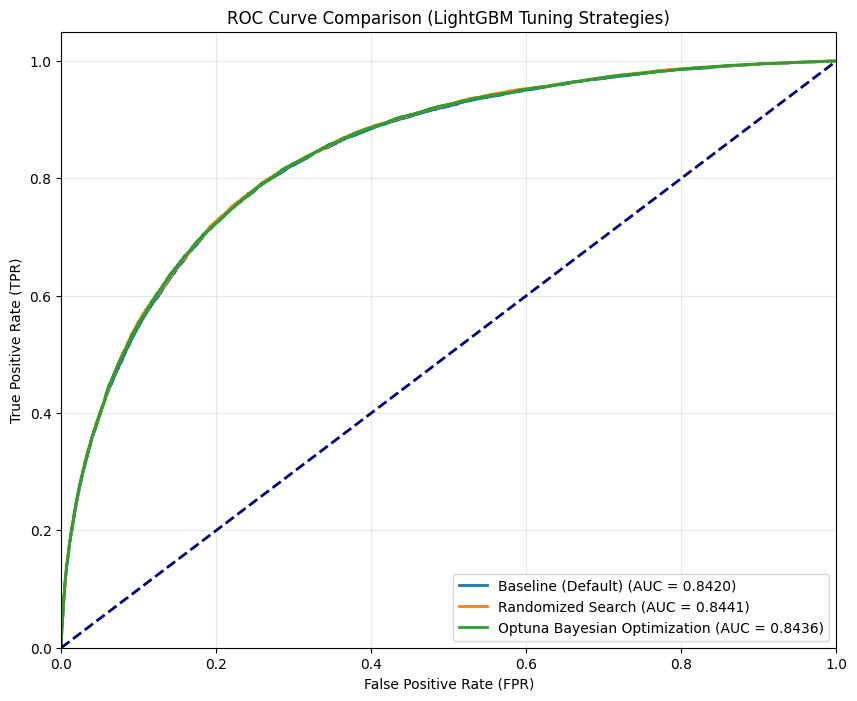

In [11]:
# 5.1 ROC Curve Comparison (LightGBM Tuning Strategies)
plt.figure(figsize=(10, 8))

for res in results_lgbm:
    name = res['Method']
    model = res['model']
    auc_score = res['ROC-AUC']
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, sample_weight=w_test)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison (LightGBM Tuning Strategies)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
# 6. Model Calibration using the Best Tuned Model
best_row = display_tuning_df.iloc[0]
best_method_name = best_row['Method']

for res in results_lgbm:
    if res['Method'] == best_method_name:
        best_tuned_model = res['model']
        break

print(f"🏆 Best Model selected for Calibration: {best_method_name}")

# Wrap with Isotonic Calibration technique
calibrated_model = CalibratedClassifierCV(best_tuned_model, method='isotonic', cv=3)

# Train the Calibrated model
calibrated_model.fit(X_train, y_train, sample_weight=w_train)

# Predict again
calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]

# Measure Calibration quality with Brier Score (closer to 0 is better)
brier = brier_score_loss(y_test, calibrated_probs, sample_weight=w_test)
print(f"Brier Score after Calibration: {brier:.4f} (lower is better, meaning probabilities are more accurate)")


🏆 Best Model selected for Calibration: Randomized Search
Brier Score after Calibration: 0.1202 (lower is better, meaning probabilities are more accurate)


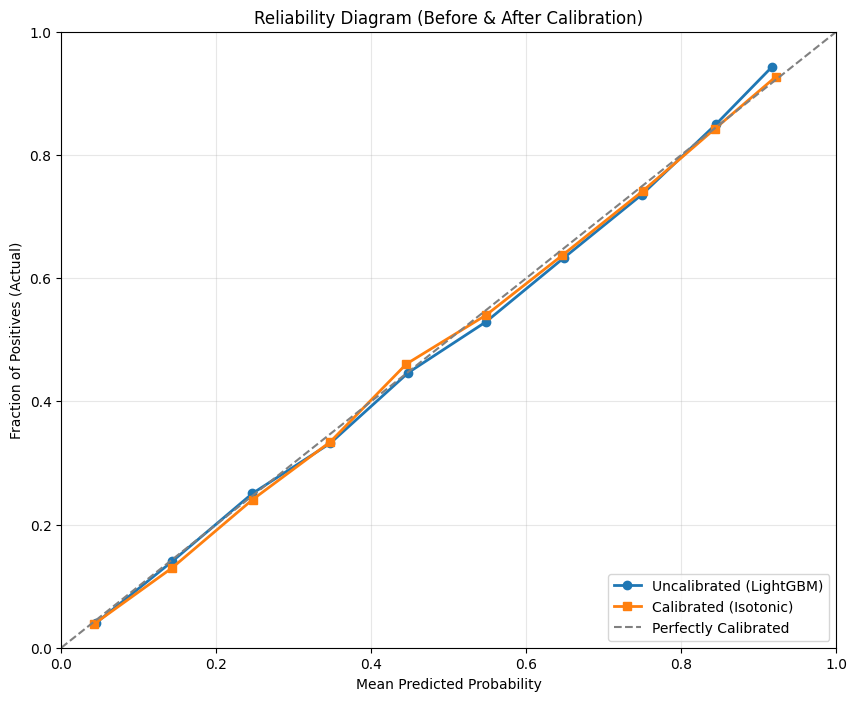

In [13]:
# 6.1 Reliability Diagram (Calibration Curve) Comparison
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 1. Uncalibrated Model (Best Tuned LightGBM)
prob_uncalibrated = best_tuned_model.predict_proba(X_test)[:, 1]
frac_true_uncal, prob_pred_uncal = calibration_curve(y_test, prob_uncalibrated, n_bins=10)
plt.plot(prob_pred_uncal, frac_true_uncal, marker='o', linewidth=2, label='Uncalibrated (LightGBM)')

# 2. Calibrated Model (Isotonic)
prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
frac_true_cal, prob_pred_cal = calibration_curve(y_test, prob_calibrated, n_bins=10)
plt.plot(prob_pred_cal, frac_true_cal, marker='s', linewidth=2, label='Calibrated (Isotonic)')

# Perfect Calibration Reference Line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Reliability Diagram (Before & After Calibration)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# 7. Save the Models for Dashboard and Interpretation
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the uncalibrated best tuned model (Required for SHAP TreeExplainer in step 04 and Dashboard)
joblib.dump(best_tuned_model, '../models/best_lightgbm_model.pkl')
print("Saved best_lightgbm_model.pkl")

# Save the calibrated model (Required for accurate probability prediction in Dashboard)
joblib.dump(calibrated_model, '../models/calibrated_lightgbm_model.pkl')
print("Saved calibrated_lightgbm_model.pkl")


Saved best_lightgbm_model.pkl
Saved calibrated_lightgbm_model.pkl
